<a href="https://colab.research.google.com/github/boseupama/Scan_Conversion_UB/blob/main/UB_Bresenhams_CircleDrawing_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Bresenham's Circle Drawing Algorithm
import matplotlib.pyplot as plt
def get_circle_points(xc, yc, r):
    pixels = []
    print("Using Bresenham's Circle Drawing Algorithm\n")
    print("Center Point:", (xc, yc))
    print("Radius:", r)
    # Initial values
    xi = 0
    yi = r
    # Initial decision parameter
    p = 3 - 2 * r
    print("Initial xi =", xi)
    print("Initial yi =", yi)
    print("Initial Decision Parameter:", p)
    print()
    step = 0
    while xi <= yi:
        #to store current values
        current_x = xi
        current_y = yi
        current_p = p
        print(
            "Step =", step,
            "xi =", current_x,
            "yi =", current_y,
            "p =", current_p
        )
        # Case 1: p < 0
        if p < 0:

            xi_next = xi + 1
            yi_next = yi

            p_next = p + 4 * xi + 6

            print("  Decision: Choose E")

            print(
                "  xi+1 =", xi_next,
                "yi+1 =", yi_next
            )

            print(
                "  Formula: p(i+1) = p(i) + 4xi + 6"
            )

            print(
                "  New p =",
                p_next
            )
        # Case 2: p >= 0
        else:

            xi_next = xi + 1
            yi_next = yi - 1

            p_next = p + 4 * (xi - yi) + 10
            print("  Decision: Choose SE")
            print(
                "  xi+1 =", xi_next,
                "yi+1 =", yi_next
            )
            print(
                "  Formula: p(i+1) = p(i) + 4(xi - yi) + 10"
            )
            print(
                "  New p =",
                p_next
            )
  #to generate 8 symmetric pixels
        symmetric_points = [
            (xc + current_x, yc + current_y),
            (xc - current_x, yc + current_y),
            (xc + current_x, yc - current_y),
            (xc - current_x, yc - current_y),

            (xc + current_y, yc + current_x),
            (xc - current_y, yc + current_x),
            (xc + current_y, yc - current_x),
            (xc - current_y, yc - current_x)
        ]
        print("  8 Symmetric Pixels:")
        for point in symmetric_points:
            if point not in pixels:
                pixels.append(point)
            print("   ", point)
        print()
        # Update values
        xi = xi_next
        yi = yi_next
        p = p_next
        step = step + 1
    return pixels







In [ ]:
def plot_circle(pixels, xc, yc, r):
    #get x and y coordinates
    xs = [p[0] for p in pixels]
    ys = [p[1] for p in pixels]
    plt.figure(figsize=(7, 7))
    #to draw calculated pixels
    plt.scatter(
        xs,
        ys,
        color="red",
        s=35,
        zorder=5,
        label="Computed Pixels"
    )
    #to draw center point
    plt.scatter(
        [xc],
        [yc],
        color="green",
        s=100,
        marker="o",
        zorder=6,
        label="Center"
    )
    #to draw ideal circle
    circle = plt.Circle(
        (xc, yc),
        r,
        fill=False,
        color="blue",
        linewidth=1.5,
        label="Bresenham Circle"
    )
    plt.gca().add_patch(circle)
    #to draw radius
    plt.plot(
        [xc, xc + r],
        [yc, yc],
        color="black",
        linestyle="--",
        linewidth=1,
        label="Radius"
    )
    plt.title(
        "Circle Drawing using Bresenham's Algorithm"
    )
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.axhline(
        0,
        color="gray",
        linewidth=0.5
    )
    plt.axvline(
        0,
        color="gray",
        linewidth=0.5
    )
    plt.grid(
        True,
        linestyle="--",
        alpha=0.6
    )
    plt.legend()
    plt.axis("equal")
    plt.savefig(
        "bresenham_circle_plot.png",
        dpi=150
    )
    print(
        "\nPlot saved as 'bresenham_circle_plot.png'"
    )
    plt.show()

Enter the center of the circle:
  xc = 0
  yc = 0

Enter the radius:
  r = 6
Using Bresenham's Circle Drawing Algorithm

Center Point: (0, 0)
Radius: 6
Initial xi = 0
Initial yi = 6
Initial Decision Parameter: -9

Step = 0 xi = 0 yi = 6 p = -9
  Decision: Choose E
  xi+1 = 1 yi+1 = 6
  Formula: p(i+1) = p(i) + 4xi + 6
  New p = -3
  8 Symmetric Pixels:
    (0, 6)
    (0, 6)
    (0, -6)
    (0, -6)
    (6, 0)
    (-6, 0)
    (6, 0)
    (-6, 0)

Step = 1 xi = 1 yi = 6 p = -3
  Decision: Choose E
  xi+1 = 2 yi+1 = 6
  Formula: p(i+1) = p(i) + 4xi + 6
  New p = 7
  8 Symmetric Pixels:
    (1, 6)
    (-1, 6)
    (1, -6)
    (-1, -6)
    (6, 1)
    (-6, 1)
    (6, -1)
    (-6, -1)

Step = 2 xi = 2 yi = 6 p = 7
  Decision: Choose SE
  xi+1 = 3 yi+1 = 5
  Formula: p(i+1) = p(i) + 4(xi - yi) + 10
  New p = 1
  8 Symmetric Pixels:
    (2, 6)
    (-2, 6)
    (2, -6)
    (-2, -6)
    (6, 2)
    (-6, 2)
    (6, -2)
    (-6, -2)

Step = 3 xi = 3 yi = 5 p = 1
  Decision: Choose SE
  xi+1 = 4 yi+1 = 4

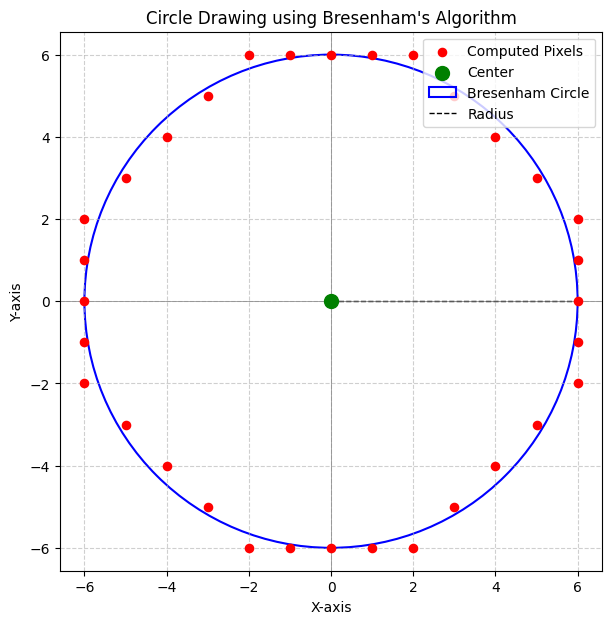

In [ ]:
def main():
    print("Enter the center of the circle:")
    xc = int(input("  xc = "))
    yc = int(input("  yc = "))
    print("\nEnter the radius:")
    r = int(input("  r = "))
    # Check radius
    if r < 0:
        print("\nRadius cannot be negative.")
        return
    pixels = get_circle_points(
        xc,
        yc,
        r
    )
    plot_circle(
        pixels,
        xc,
        yc,
        r
    )
if __name__ == "__main__":
    main()